In [124]:
import pandas as pd

In [125]:
results_df =  pd.read_csv('C:\\Users\Ronza\Dev\DP-MSD\\amazon\\results\\results_from_server\Amazon_Matroid_Results.csv')

In [126]:
results_df.head()

,alg,k,eps,private,lambda_param,gamma,rep,value,relevance,diversity,queries,time_sec,timestamp
0,RandomBaseline,4,0.1,True,0.1,0.2,0,0.039380,0.014749,0.261063,1,0.0049,1771324676168
1,LocalSearch_Matroid,4,0.1,True,0.1,0.2,0,0.111293,0.086032,0.338642,305117,183.3678,1771324859536
2,DPSampleLocalSearch,4,0.1,True,0.1,0.2,0,0.111293,0.086032,0.338642,23002,381.2319,1771325240768
3,RandomBaseline,4,0.1,True,0.1,0.2,1,0.036887,0.003980,0.333051,23003,0.0017,1771325240770
4,DPSampleLocalSearch,4,0.1,True,0.1,0.2,1,0.111293,0.086032,0.338642,23002,396.5277,1771325637298


# Amazon Matroid


## Impact of k on score


In [127]:
results_df['alg'] = results_df['alg'].replace(
    {
        'LocalSearch_Matroid': 'LS',
        'DPSampleLocalSearch': 'DP-SLS',
        'RandomBaseline': 'Random'
    }
)

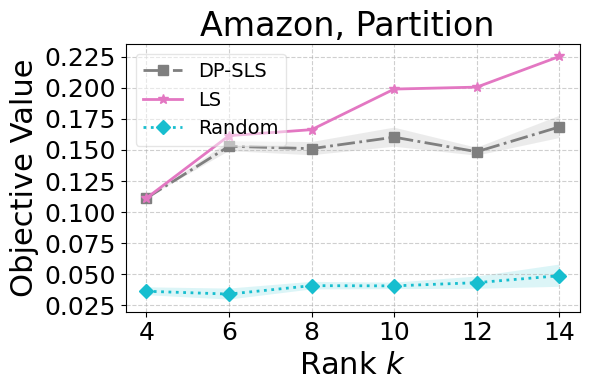

In [139]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon, Partition ', fontsize=24)

plt.xticks(range(4,16,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_val.pdf')
plt.show()

## Impact of eps on score


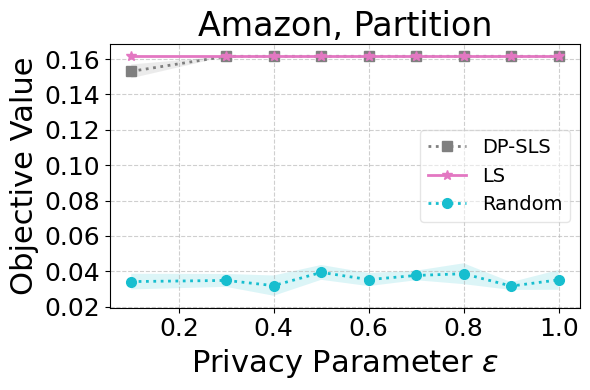

In [138]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6
eps_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )
    line, = plt.plot(
    alg_data['eps'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['eps'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon, Partition', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_matroid_eps_on_val.pdf')
plt.show()

## Impact of k on num queries

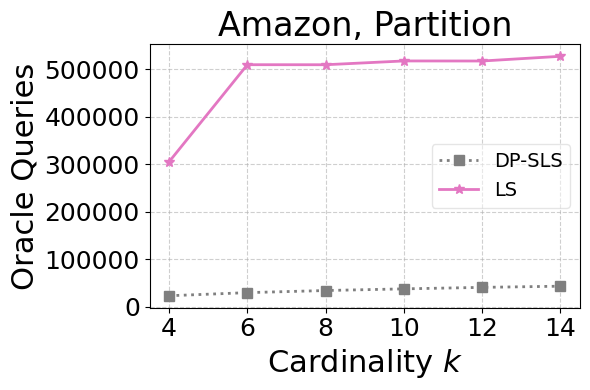

In [137]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1) & ~results_df['alg'].isin(['Random'])]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Amazon, Partition', fontsize=24)

plt.xticks(range(4,16,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_queries.pdf')
plt.show()

## Impact of k on execution time


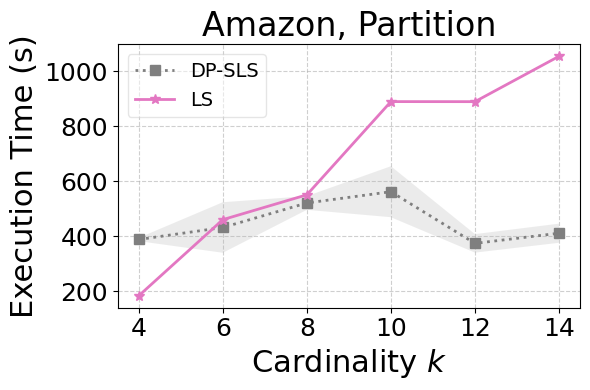

In [136]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1) & ~results_df['alg'].isin(['Random'])]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Amazon, Partition', fontsize=24)

plt.xticks(range(4,16,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_time.pdf')
plt.show()